<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/worksheet_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Load dataset from uploaded file
import io
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

# Display first few rows
df.head()

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
def softmax(z):
    """
    Compute softmax probabilities for a given input matrix.
    Parameters:
        z: Logits of shape (m, n) — m samples, n classes
    Returns:
        Softmax probability matrix of shape (m, n)
    """
    z_shifted = z - np.max(z, axis=1, keepdims=True)  # Numerical stability
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# --- Test Case (Do Not Modify) ---
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


In [4]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model.
    Parameters:
        X: Feature matrix (n, d)
        W: Weight matrix (d, c)
        b: Bias vector (c,)
    Returns:
        Predicted class labels of shape (n,)
    """
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    predicted_classes = np.argmax(y_pred, axis=1)
    return predicted_classes

# --- Test Case (Do Not Modify) ---
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


In [5]:
def loss_softmax(y_pred, y):
    """
    Compute categorical cross-entropy loss.
    Parameters:
        y_pred: Predicted probabilities (n, c)
        y: True labels one-hot encoded (n, c)
    Returns:
        float: Cross-entropy loss
    """
    epsilon = 1e-12  # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    n = y.shape[0]
    loss = -np.sum(y * np.log(y_pred)) / n
    return loss

# --- Test Case (Do Not Modify) ---
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([[0.9, 0.05, 0.05],
                            [0.1, 0.85, 0.05],
                            [0.05, 0.1, 0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1, 0.05, 0.85],
                              [0.85, 0.1, 0.05]])

loss_correct   = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, \
    f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


In [6]:
def cost_softmax(X, y, W, b):
    """
    Compute average softmax regression cost over all samples.
    Parameters:
        X: Feature matrix (n, d)
        y: True labels one-hot encoded (n, c)
        W: Weight matrix (d, c)
        b: Bias vector (c,)
    Returns:
        float: Average cross-entropy loss
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    total_loss = loss_softmax(y_pred, y)  # Already averaged inside loss_softmax
    return total_loss

# --- Test Case (Do Not Modify) ---
X_correct   = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct   = np.array([[1, 0], [0, 1]])
W_correct   = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct   = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct   = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, \
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
print("Cost for correct prediction:  ", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction:   0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


In [7]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of cost function w.r.t weights and biases.
    Parameters:
        X: Feature matrix (n, d)
        y: True labels one-hot encoded (n, c)
        W: Weight matrix (d, c)
        b: Bias vector (c,)
    Returns:
        grad_W (d, c), grad_b (c,)
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n   # Gradient w.r.t weights
    grad_b = np.sum(y_pred - y, axis=0) / n  # Gradient w.r.t biases
    return grad_W, grad_b

# --- Test Case (Do Not Modify) ---
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test         = np.dot(X_test, W_test) + b_test
y_pred_test    = softmax(z_test)
grad_W_manual  = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual  = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), f"Test failed: grad_W mismatch"
assert np.allclose(grad_b, grad_b_manual), f"Test failed: grad_b mismatch"
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


In [8]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.
    Parameters:
        X: Feature matrix (n, d)
        y: True labels one-hot encoded (n, c)
        W: Weight matrix (d, c)
        b: Bias vector (c,)
        alpha: Learning rate
        n_iter: Number of iterations
        show_cost: Print cost every 100 iterations
    Returns:
        W, b, cost_history
    """
    cost_history = []

    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute and store cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print cost at regular intervals
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

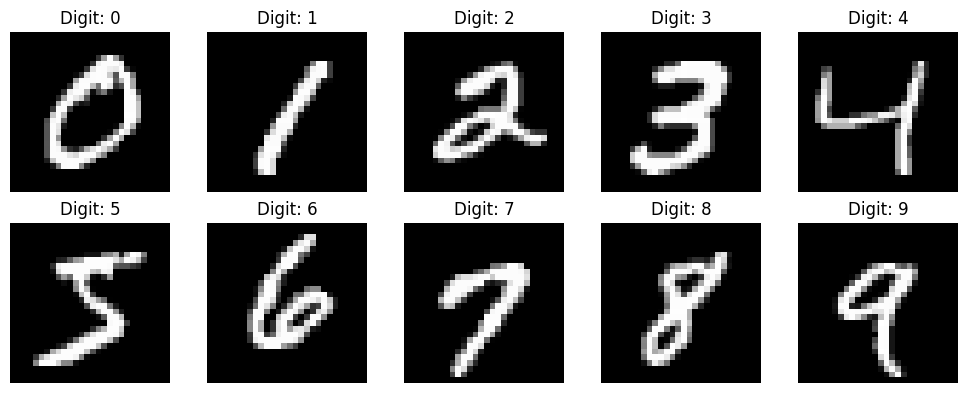

Shape check passed!
X_train: (48000, 784) | y_train: (48000,)
X_test:  (12000, 784)  | y_test:  (12000,)


In [10]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Use the df already loaded in Cell 1
y_raw = df.iloc[:, 0].values   # First column = label
X_raw = df.iloc[:, 1:].values  # Remaining columns = pixels

# Normalize
X_raw = X_raw / 255.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Plot sample digits
plot_sample_images(X_raw, y_raw)

# Shape check
assert len(X_train) == len(y_train), \
    f"Shape mismatch: X={len(X_train)}, y={len(y_train)}"
print("Shape check passed!")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

Iteration 0: Cost = 2.203697
Iteration 100: Cost = 0.607266
Iteration 200: Cost = 0.489570
Iteration 300: Cost = 0.440973
Iteration 400: Cost = 0.412894
Iteration 500: Cost = 0.394023
Iteration 600: Cost = 0.380197
Iteration 700: Cost = 0.369486
Iteration 800: Cost = 0.360857
Iteration 900: Cost = 0.353704
Iteration 999: Cost = 0.347699


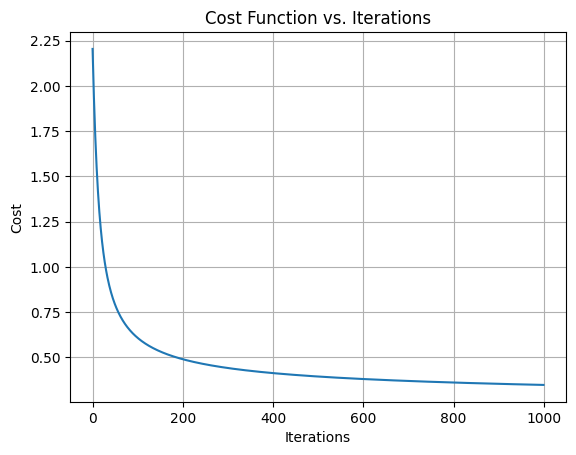

In [11]:
# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train_enc = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test_enc  = encoder.transform(y_test.reshape(-1, 1))

# Initialize weights and biases
d = X_train.shape[1]      # 784 features
c = y_train_enc.shape[1]  # 10 classes

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha  = 0.1
n_iter = 1000

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train_enc, W, b, alpha, n_iter, show_cost=True
)

# Plot cost history
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


Confusion Matrix:
[[1126    0    5    2    3   12    9    2   13    3]
 [   0 1274    7   11    1    5    1    4   18    1]
 [   1   15 1027   17   19    4   27   25   31    8]
 [   8    5   33 1052    1   54    9    8   28   21]
 [   1    5    7    1 1093    0   10    4    4   51]
 [  22   14   14   44   11  921   14    7   42   15]
 [   7    2   10    1   11   15 1119    2   10    0]
 [   7   27   24    5   15    3    0 1183    7   28]
 [   9   28   14   34    9   31   14    7 1000   14]
 [   8    6   10   18   43    9    0   38    9 1053]]
Precision: 0.90
Recall:    0.90
F1-Score:  0.90


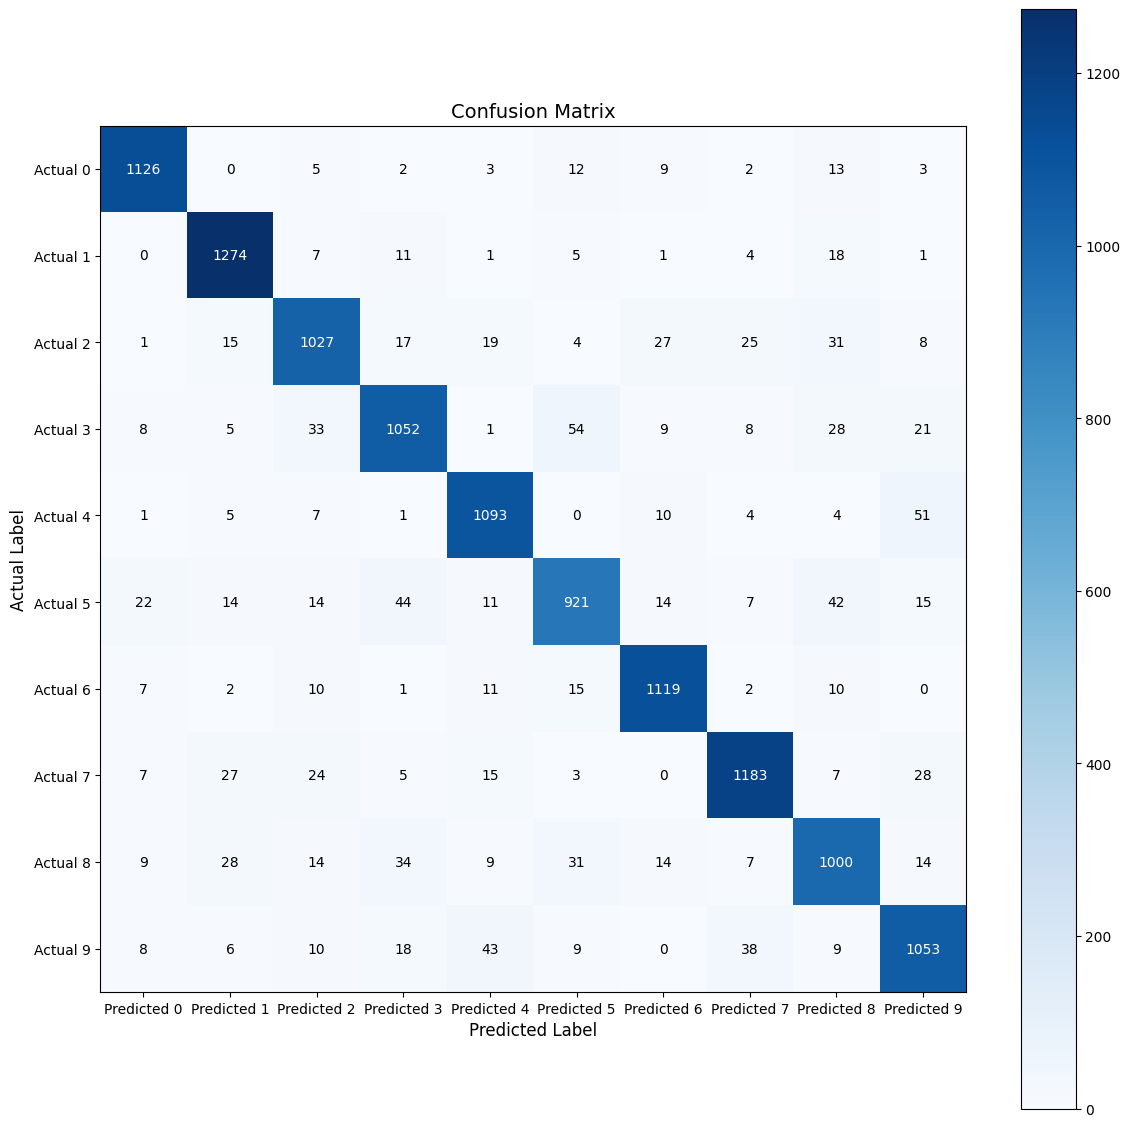

In [12]:
def evaluate_classification(y_true, y_pred):
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict
y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test_enc, axis=1)

# Evaluate
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

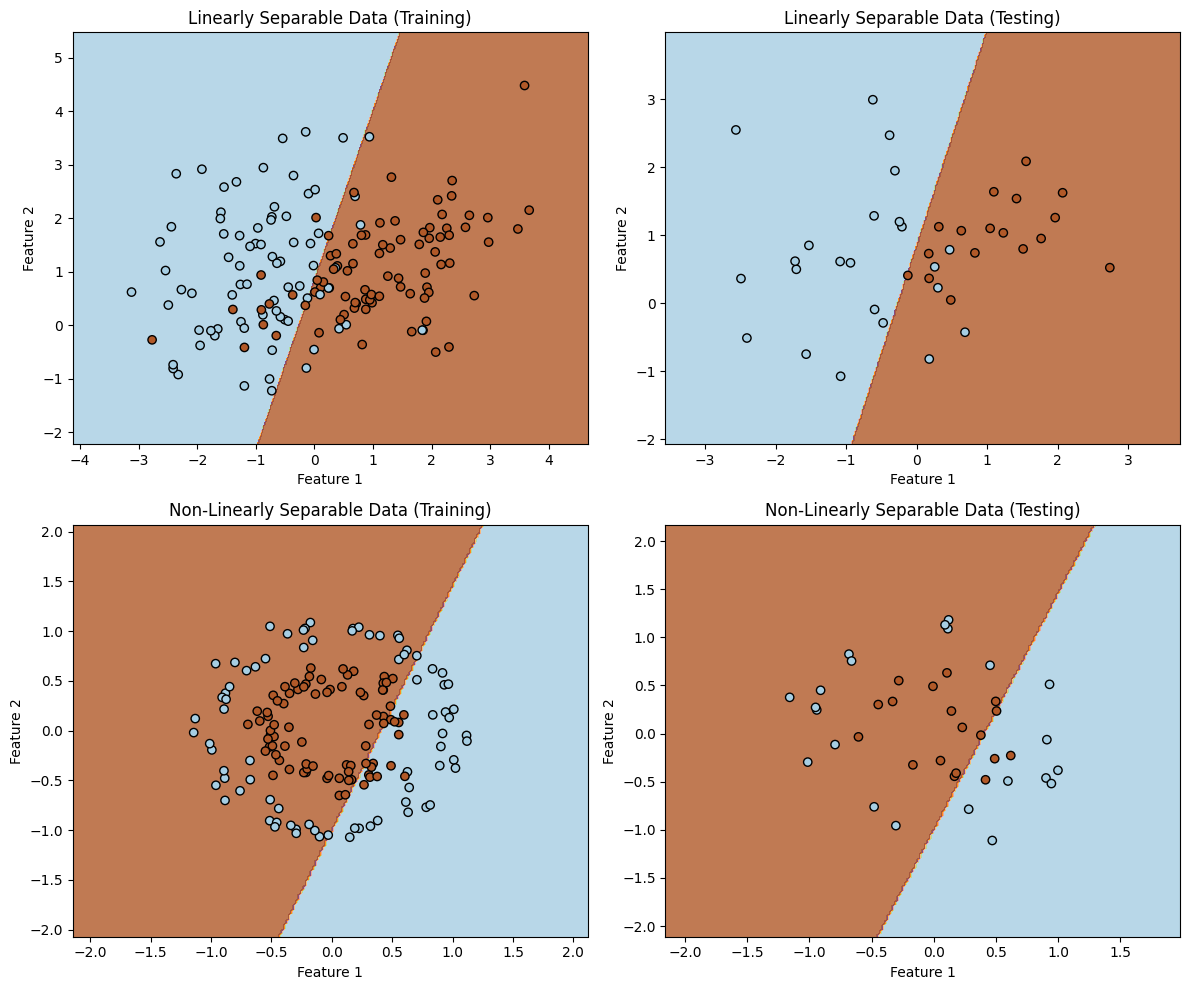

In [13]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# Linearly separable data
X_lin, y_lin = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_tr_lin, X_te_lin, y_tr_lin, y_te_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)
model_lin = LogisticRegression()
model_lin.fit(X_tr_lin, y_tr_lin)

# Non-linearly separable data (circles)
X_nonlin, y_nonlin = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
X_tr_nonlin, X_te_nonlin, y_tr_nonlin, y_te_nonlin = train_test_split(
    X_nonlin, y_nonlin, test_size=0.2, random_state=42
)
model_nonlin = LogisticRegression()
model_nonlin.fit(X_tr_nonlin, y_tr_nonlin)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(axes[0,0], model_lin,    X_tr_lin,    y_tr_lin,    'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0,1], model_lin,    X_te_lin,    y_te_lin,    'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1,0], model_nonlin, X_tr_nonlin, y_tr_nonlin, 'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1,1], model_nonlin, X_te_nonlin, y_te_nonlin, 'Non-Linearly Separable Data (Testing)')
plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()